<a href="https://colab.research.google.com/github/OmarArias-Gaguancela/QuickProt/blob/main/QuickProt_PepSeq_Skyline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img src="https://raw.githubusercontent.com/OmarArias-Gaguancela/LOGOS_OAG/main/QuickProt PepSeq.jpg" width="180" height="100">

# **QuickProt-PepSeq (Skyline)**: QuickProt-PepSeq aims to map DIA-detected peptides to a given amino acid sequence region. This is especially useful when trying to assess the number of peptides that were detected in a DIA dataset for a given protein domain, N-terminal region, C-terminal region, etc.

## **Requirements:**
## 1. Create a folder in MyDrive where analyzed data will be stored
## 2. QuickProt-DIA (Skyline) processed table **"DIA_RESULTS_UPDATED.csv"**
## 3. Aminoacid sequence of a given region of interest**

## **Outputs:**
### 1. All generated spreadsheets will be stored in a folder called **"TABLES"**
### 2. All figures will be stored in a folder called **"PLOTS"**




In [ ]:
#@title ##**Mounts drive and changes the directory to the folder previously created**

from google.colab import drive
import os
from IPython.display import display
import ipywidgets as widgets

# Mount Google Drive
drive.mount('/content/drive')

# Create a text input widget with a longer line
folder_input = widgets.Text(
    value='',
    placeholder='Enter the name of the folder you created',
    description='Folder:',
    layout=widgets.Layout(width='50%')
)

# Display the widget
display(folder_input)

# Function to change directory based on user input
def change_directory(change):
    folder_name = change['new']
    os.chdir(f'/content/drive/MyDrive/{folder_name}')
    print(f"Current directory: {os.getcwd()}")

# Link the widget to the function
folder_input.observe(change_directory, names='value')



Mounted at /content/drive


Text(value='', description='Folder:', layout=Layout(width='50%'), placeholder='Enter the name of the folder yo…

Current directory: /content/drive/MyDrive/QUICKPROT_FOR_MANUSCRIPT/DIA-detected_peptides_in_target_sequence_Skyline


In [ ]:
#@title **Install neccesary packages**
import os

os.system('pip install xlsxwriter > /dev/null 2>&1')

print("Packages were installed successfully.")
os.makedirs('PLOTS', exist_ok=True)

Packages were installed successfully.


In [ ]:
#@title ##**DIA-detected peptides in a given amino acid sequence region**
#@markdown - Enter a query sequence, and the code will provide an excel sheet output "PeptideMatches.xlsx" with the number of peptides found in the DIA proteome of your dataset
#@markdown - Sheet "Matches ExpGroup" will have a list of peptide match numbers per experimental group whereas "Peptides ExpGroup" will contain the peptide squences of the matches
#@markdown - Sheet "Matches Sample" will have a list of peptide match numbers per sample whereas "Peptides Sample" will contain the peptide squences of the matches

import pandas as pd
import re

output_dir = 'TABLES'
os.makedirs(output_dir, exist_ok=True)

output_dir = 'PLOTS'
os.makedirs(output_dir, exist_ok=True)

query_sequence = "DAESRPTPMGPPPTSHFHVLADTPSG LVPLQPKTPQQTSASQQMLNFPDKGKEKPTDMQNFGLRTDMYTKKNVPSKSKAAASATRE WTEQETLLLLEALEMYKDDWNKVSEHVGSRTQDECILHFLRLPIEDPYLEDSEASLGPLA YQPIPFSQSGNPVMSTVAFLASVVDPRVASAAAKSALEEFSKMKEEVPTALVEAHVRKVE EAAKVTGKADPAFGLESSGIAGTTSDEPERIEESGNDEARVEGQATDEKKEPKEPREGGG AIEEEAKEKTSEAPKKDEEKGKEGDSEKESEKSDGDPIVDPEKEKEPKEGQEEVLKEVVE SEGERKTKVERDIGEGNLSTAAAAALAAAAVKAKHLAAVEERKIKSLVALLVETQMKKLE IKLRHFEELETIMDREREALEYQRQQLLADRQAFHMEQLKYAEMRARQQHFQQMHQQQQQ PPPALPPGSQPIPPTGAAGPPAVHGLAVAPASVVPAPAGSGAPPGSLGPSEQIGQAGSTA GPQQQQPAGAPQPGAVPPGVPPPGPHGPSPFPNQQTPPSMMPGAVPGSGHPGVAGNAPLG LPFGMPPPPPPPAPSIIPFGSLADSISINLPAPPNLHGHHHHLPFAPGTLPPPNLPVSMA NPLHPNLPATTTMPSSLPLGPGLGSAAAQSPAIVAAVQGNLLPSASPLPDPGTPLPPDPT APSPGTVTPVPPPQ"  #@param {type:"string"}
df = pd.read_csv('DIA_RESULTS_UPDATED.csv', usecols=['Experimental groups', 'Sample', 'Peptide'])
def match_sequences(df, query_sequence):

    exp_group_results = []
    exp_group_common_sequences = []

    sample_results = []
    sample_common_sequences = []

    experimental_groups = df['Experimental groups'].unique()
    for group in experimental_groups:
        group_df = df[df['Experimental groups'] == group]
        unique_sequences = set(group_df['Peptide'])
        matches = 0
        common_seqs = set()

        for seq in unique_sequences:
            if seq in query_sequence:
                matches += 1
                common_seqs.add(seq)

        exp_group_results.append([group, matches])
        for seq in common_seqs:
            exp_group_common_sequences.append([group, seq])

    samples = df['Sample'].unique()
    for sample in samples:
        sample_df = df[df['Sample'] == sample]
        unique_sequences = set(sample_df['Peptide'])
        matches = 0
        common_seqs = set()

        for seq in unique_sequences:
            if seq in query_sequence:
                matches += 1
                common_seqs.add(seq)

        sample_results.append([sample, matches])
        for seq in common_seqs:
            sample_common_sequences.append([sample, seq])

    exp_group_df = pd.DataFrame(exp_group_results, columns=['Experimental groups', 'Number of peptide matches'])
    exp_group_common_df = pd.DataFrame(exp_group_common_sequences, columns=['Experimental groups', 'Common Stripped.Sequence'])

    sample_df = pd.DataFrame(sample_results, columns=['Sample', 'Number of peptide matches'])
    sample_common_df = pd.DataFrame(sample_common_sequences, columns=['Sample', 'Common Stripped.Sequence'])

    with pd.ExcelWriter('TABLES/PeptideMatches.xlsx') as writer:
        exp_group_df.to_excel(writer, sheet_name='Matches ExpGroup', index=False)
        exp_group_common_df.to_excel(writer, sheet_name='Peptides ExpGroup', index=False)
        sample_df.to_excel(writer, sheet_name='Matches Sample', index=False)
        sample_common_df.to_excel(writer, sheet_name='Peptides Sample', index=False)

match_sequences(df, query_sequence)

print("The results have been exported to TABLES/PeptideMatches.xlsx")

The results have been exported to TABLES/PeptideMatches.xlsx


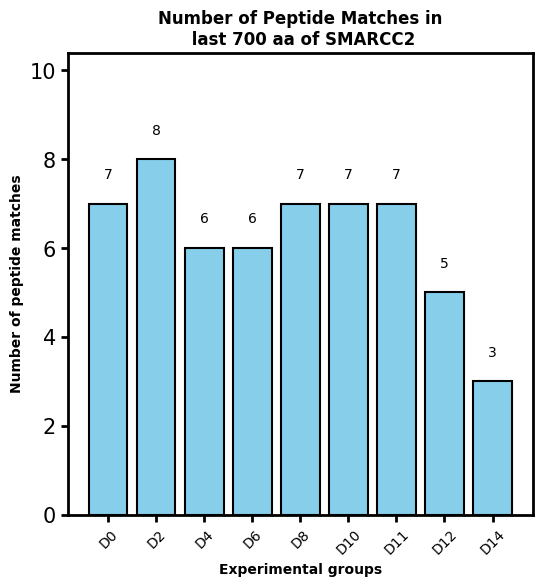

In [ ]:
#@title ##**Bar plot representation**
import pandas as pd
import matplotlib.pyplot as plt
from ipywidgets import widgets, Button, VBox, HBox

file = 'TABLES/PeptideMatches.xlsx'
df = pd.read_excel(file, sheet_name='Matches ExpGroup')

def plot_bar_chart(order, target_region):
    plt.figure(figsize=(6, 6))
    ordered_df = df.set_index('Experimental groups').loc[list(order)]
    bars = plt.bar(ordered_df.index, ordered_df['Number of peptide matches'], color='skyblue', edgecolor='black', linewidth=1.5)
    plt.xlabel('Experimental groups', fontsize=10, fontweight='bold')
    plt.ylabel('Number of peptide matches', fontsize=10, fontweight='bold')
    plt.title(f'Number of Peptide Matches in\n {target_region}', fontweight='bold', fontsize=12)
    plt.tick_params(axis='x', which='both', bottom=True, length=5, width=2, color='black')
    plt.tick_params(axis='y', which='both', left=True, length=5, width=2, color='black')
    plt.yticks(fontsize=15)
    plt.xticks(rotation=45, fontsize=10)

    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, int(yval), ha='center', va='bottom')

    ax1 = plt.gca()
    for spine in ax1.spines.values():
        spine.set_linewidth(2)
        spine.set_color("k")
    ax1.margins(y=0.3)
    plt.savefig('PLOTS/peptide_matches.tiff', format='tiff', dpi=300)
    plt.show()

experimental_groups = df['Experimental groups'].tolist()
order_widget = widgets.SelectMultiple(
    options=experimental_groups,
    value=experimental_groups,
    description='Order',
    disabled=False
)

target_region_widget = widgets.Text(
    value='Write the target region of interest',
    description='Title:',
    disabled=False
)

def move_up(b):
    selected = order_widget.value
    if not selected:
        return
    current_order = list(order_widget.options)
    for item in selected:
        idx = current_order.index(item)
        if idx > 0:
            current_order[idx], current_order[idx - 1] = current_order[idx - 1], current_order[idx]
    order_widget.options = current_order
    order_widget.value = selected

def move_down(b):
    selected = order_widget.value
    if not selected:
        return
    current_order = list(order_widget.options)
    for item in reversed(selected):
        idx = current_order.index(item)
        if idx < len(current_order) - 1:
            current_order[idx], current_order[idx + 1] = current_order[idx + 1], current_order[idx]
    order_widget.options = current_order
    order_widget.value = selected

up_button = Button(description="Move Up", style={'font_weight': 'bold', 'button_color': '#4CAF50', 'font_size': '16px'})
down_button = Button(description="Move Down", style={'font_weight': 'bold', 'button_color': '#4CAF50', 'font_size': '16px'})
up_button.on_click(move_up)
down_button.on_click(move_down)

display_button = Button(description="Display Plot", style={'font_weight': 'bold', 'button_color': '#4CAF50', 'font_size': '16px'})

def on_display_button_click(b):
    plot_bar_chart(order_widget.value, target_region_widget.value)

display_button.on_click(on_display_button_click)

display(VBox([target_region_widget, order_widget, HBox([up_button, down_button]), display_button]))